In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler,StandardScaler
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [3]:
import pandas as pd
data1=pd.read_excel("data/data_Ra_Density_my_model.xlsx")
data2=pd.read_excel("data/data_density_Ra_without_aug.xlsx")
data1.columns=['p','v','h','t','Ra','density']
data1=data1.loc[:86]
data2=data2[data1.columns]
data_combined=pd.concat([data1,data2],ignore_index=True)
data_combined.loc[data_combined["t"] == 300, "t"] = 30

data_combined['ved']=(data_combined['p']*1000*1000)/(data_combined['v'] * data_combined['t']  *data_combined['h'])
data_combined['ped']=(data_combined['p'])/(data_combined['v'] )
data_combined['led']=(data_combined['p']*1000)/(data_combined['v'] * data_combined['h'])

data_combined=data_combined[data_combined['ved']<=1000]
data_combined=data_combined[data_combined['density']>=80]

data_combined = data_combined[data_combined['t'] != 250.0]

In [4]:
data_combined['is_real_density'] = [True if i < 86 else False for i in range(len(data_combined))]

dup_params = data_combined.duplicated(subset=['p', 'v', 'h', 't'], keep=False)
data_combined1 = data_combined.sort_values(by='is_real_density', ascending=False)
data_cleaned = data_combined1.drop_duplicates(subset=['p', 'v', 'h', 't', 'Ra'], keep='first')

data_cleaned = data_cleaned.drop([76,208])
data_cleaned=data_cleaned[['p','v','h','t','Ra','density']]


In [5]:
data_cleaned=data_cleaned[['p','v','h', 't','Ra','density']]

In [11]:
data_cleaned.to_excel("data_cleaned.xlsx", index=False)

In [5]:
data_cleaned.describe()

,p,v,h,t,Ra,density
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,198.778135,914.474477,97.395498,34.662379,10.023863,97.595446
std,71.094672,500.540384,23.920520,11.624439,3.681539,3.157474
min,60.000000,90.000000,10.000000,20.000000,2.600000,80.600000
25%,150.000000,600.000000,80.000000,30.000000,7.042027,97.273924
50%,195.000000,800.000000,100.000000,30.000000,10.482101,98.610000
75%,225.000000,1100.000000,117.000000,40.000000,11.652665,99.495000
max,400.000000,3400.000000,180.000000,60.000000,27.090754,99.999300


In [14]:
print(data_cleaned.skew(numeric_only=True).sort_values(ascending=False))


v          1.651080
Ra         1.340452
t          0.818636
p          0.596763
h         -0.234099
density   -2.531623
dtype: float64


In [8]:

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from scipy.special import inv_boxcox
from scipy.stats import boxcox, entropy
import optuna
from sklearn.preprocessing import MinMaxScaler



data_transformed = data_cleaned.copy()


metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=data_cleaned)

c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:



# ==== 2. Fonction d'objectif pour Optuna ====
def compute_js_divergence(real, synthetic):
    """Calcule la moyenne des JS divergence pour chaque colonne."""
    total_div = 0
    for col in real.columns:
        real_col = np.histogram(real[col], bins=20, density=True)[0] + 1e-6
        synth_col = np.histogram(synthetic[col], bins=20, density=True)[0] + 1e-6
        m = 0.5 * (real_col + synth_col)
        js = 0.5 * (entropy(real_col, m) + entropy(synth_col, m))
        total_div += js
    return total_div / len(real.columns)


def objective(trial):
    # ==== 3. Paramètres à optimiser ====
    epochs = trial.suggest_int("epochs", 1000, 5000, step=1000)
    batch_size = trial.suggest_categorical("batch_size", [16,32,64])
    pac = trial.suggest_categorical("pac", [1])
    embedding_dim = trial.suggest_categorical("embedding_dim", [128, 256,384])
    gen_dim = trial.suggest_categorical("generator_dim", [ (256, 256), (256, 128),(512,256),(512, 128), (512, 512)])
    disc_dim = trial.suggest_categorical("discriminator_dim", [ (256, 256),(512,256), (512, 128), (512, 512)])
    

    # ==== 4. Modèle CTGAN ====
    model = CTGANSynthesizer(
        metadata=metadata,
        epochs=epochs,
        batch_size=batch_size,
        pac=pac,
        embedding_dim=embedding_dim,
        generator_dim=gen_dim,
        discriminator_dim=disc_dim,
        
        verbose=False
    )

    try:
        model.fit(data_cleaned)
        synth = model.sample(num_rows=1000)

    

        real_rescaled = MinMaxScaler().fit_transform(data_cleaned)
        synth_rescaled = MinMaxScaler().fit_transform(synth[data_cleaned.columns])

        # JS divergence (plus petit = meilleur)
        divergence = compute_js_divergence(pd.DataFrame(real_rescaled), pd.DataFrame(synth_rescaled))
        return divergence

    except Exception as e:
        print("Erreur :", e)
        return float('inf')


# ==== 5. Lancement d’Optuna ====
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, n_jobs=-1)

# ==== 6. Meilleurs paramètres ====
print("Meilleurs hyperparamètres trouvés :")
print(study.best_params)


[I 2025-06-20 17:01:58,348] A new study created in memory with name: no-name-690d831e-baff-48f4-b199-09b7c650806b
c:\Users\Administrateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (256, 256) which is of type tuple.
  warnings.warn(message)
c:\Users\Administrateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (256, 128) which is of type tuple.
  warnings.warn(message)
c:\Users\Administrateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (512, 256) wh

In [9]:


final_ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=6000,
    batch_size=32,
    pac=1,
    embedding_dim=256,
    generator_dim=(256, 256),
    discriminator_dim=(512, 256),
    verbose=True 
)

final_ctgan.fit(data_transformed)


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\sdv\single_table\base.py:162: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\sdv\single_table\base.py:128: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-0.24) | Discrim. (-0.18): 100%|██████████| 6000/6000 [14:20<00:00,  6.97it/s]


In [10]:
synthetic_data = final_ctgan.sample(num_rows=1000)


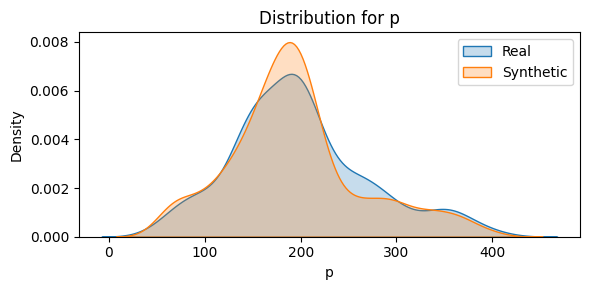

p: KS-stat = 0.113, p-value = 0.004


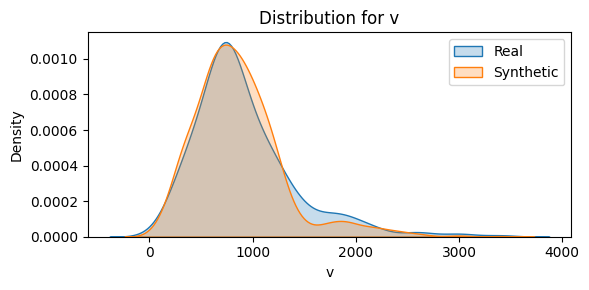

v: KS-stat = 0.079, p-value = 0.096


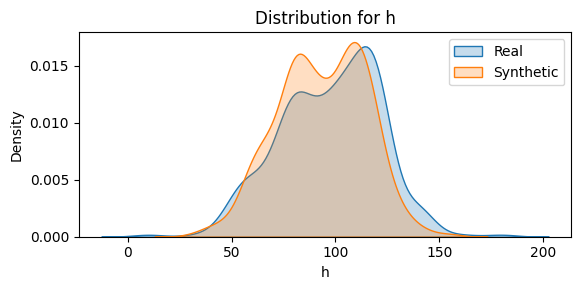

h: KS-stat = 0.153, p-value = 0.000


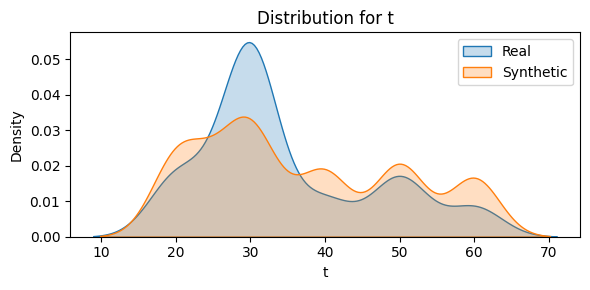

t: KS-stat = 0.158, p-value = 0.000


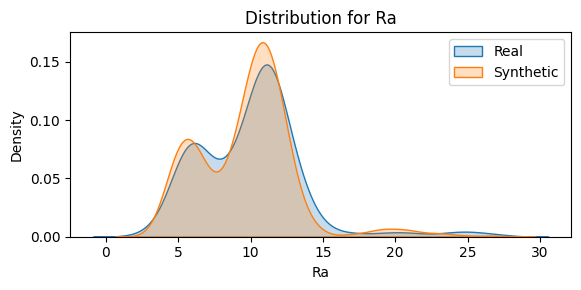

Ra: KS-stat = 0.078, p-value = 0.106


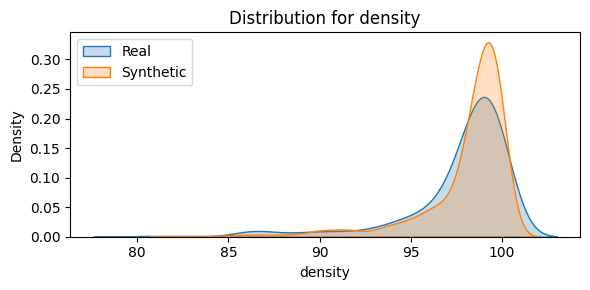

density: KS-stat = 0.107, p-value = 0.008


In [11]:
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

for col in data_cleaned.columns:
  
    plt.figure(figsize=(6, 3))
    sns.kdeplot(data_cleaned[col], label='Real', fill=True)
    sns.kdeplot(synthetic_data[col], label='Synthetic', fill=True)
    plt.title(f'Distribution for {col}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    
    # Test KS
    ks_stat, p_value = ks_2samp(data_cleaned[col], synthetic_data[col])
    print(f"{col}: KS-stat = {ks_stat:.3f}, p-value = {p_value:.3f}")


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split


real_labeled = data_cleaned.copy()
real_labeled['source'] = 0

synthetic_labeled = synthetic_data.copy()
synthetic_labeled['source'] = 1


combined = pd.concat([real_labeled, synthetic_labeled], ignore_index=True)

X = combined.drop(columns='source')
y = combined['source']
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

clf = RandomForestClassifier(n_estimators=500, random_state=42)

# Évaluer la capacité de discrimination avec cross-validation
scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')
print(f"AUC (moyenne sur 5 folds) = {scores.mean():.3f}")


AUC (moyenne sur 5 folds) = 0.665


In [60]:
synthetic_data.describe()

,p,v,h,t,Ra,density
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,194.804778,892.590012,92.556556,37.094444,9.647620,98.031067
std,68.648827,440.288467,21.820409,13.679429,3.697581,2.803822
min,60.000000,90.000000,33.600000,20.000000,2.840059,83.436122
25%,148.200000,636.399131,75.950000,25.000000,7.058754,97.981072
50%,186.350000,840.562662,92.800000,30.000000,9.773398,98.936743
75%,224.775000,1056.852874,110.400000,50.000000,11.147311,99.600647
max,400.000000,3400.000000,154.100000,60.000000,27.090754,99.999300


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler,StandardScaler
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data_combined=pd.concat([synthetic_data,data_cleaned],ignore_index=True)

In [19]:
data_combined.describe()

,p,v,h,t,Ra,density
count,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000
mean,193.585761,879.770837,95.157938,35.900164,9.931278,97.673497
std,68.004026,468.458450,23.140544,12.535517,3.599258,3.095402
min,60.000000,90.000000,10.000000,20.000000,2.600000,80.600000
25%,150.000000,600.000000,80.000000,30.000000,7.061749,97.540706
50%,190.000000,800.000000,97.900000,30.000000,10.380000,98.710000
75%,225.000000,1060.171276,112.800000,50.000000,11.616931,99.428689
max,400.000000,3400.000000,180.000000,60.000000,27.090754,99.999300


In [13]:
X=data_combined[['p','v','h', 't']]
y=data_combined[['Ra','density']]



Ra = y['Ra'].values.flatten()
density = y['density'].values.flatten()


scaler_X = RobustScaler()
X_scaled = scaler_X.fit_transform(X[['p', 'v', 'h', 't']])


Ra_shifted = Ra + 1e-5  
Ra_boxcox, lambda_ra = boxcox(Ra_shifted)
scaler_Ra = RobustScaler()
Ra_scaled = scaler_Ra.fit_transform(Ra_boxcox.reshape(-1, 1))


scaler_density = RobustScaler()
density_scaled = scaler_density.fit_transform(density.reshape(-1, 1))


y_scaled = np.hstack([Ra_scaled, density_scaled])


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.3, random_state=42, shuffle=True)


In [14]:
def print_metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"—— Résultats pour {name} ——")
    print(f"R²    : {r2:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAPE  : {mape:.2f}%")
    print()

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, PReLU, Dropout
from tensorflow.keras.optimizers import Adam


model = Sequential([
 Dense(512, input_dim=X_train.shape[1]),
    BatchNormalization(),
    PReLU(),

    Dense(160),
    BatchNormalization(),
    PReLU(),
    Dropout(0.5),


    Dense(2, activation='linear')
])
    
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

history = model.fit(X_train, y_train, epochs=1000, batch_size=64,
                    validation_split=0.1, verbose=0)

y_pred_scaled = model.predict(X_test)

Ra_pred_scaled = y_pred_scaled[:, 0].reshape(-1, 1)
density_pred_scaled = y_pred_scaled[:, 1].reshape(-1, 1)


Ra_pred_boxcox = scaler_Ra.inverse_transform(Ra_pred_scaled)
Ra_pred = inv_boxcox(Ra_pred_boxcox.flatten(), lambda_ra)


density_pred = scaler_density.inverse_transform(density_pred_scaled).flatten()

Ra_test_scaled = y_test[:, 0].reshape(-1, 1)
density_test_scaled = y_test[:, 1].reshape(-1, 1)

Ra_test_boxcox = scaler_Ra.inverse_transform(Ra_test_scaled)
Ra_test = inv_boxcox(Ra_test_boxcox.flatten(), lambda_ra)

density_test = scaler_density.inverse_transform(density_test_scaled).flatten()


print_metrics(Ra_test, Ra_pred, "Ra")
print_metrics(density_test, density_pred, "Density")



c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
—— Résultats pour Ra ——
R²    : 0.4023
MAE   : 1.8637
RMSE  : 2.4456
MAPE  : 22.87%

—— Résultats pour Density ——
R²    : -0.1148
MAE   : 1.7097
RMSE  : 2.8592
MAPE  : 1.79%



In [26]:
def inverse_transform(pred_scaled, lambda_ra, scaler_ra, scaler_dens):
    ra_inv = scaler_ra.inverse_transform(pred_scaled[:, 0].reshape(-1, 1))
    ra_orig = np.exp(np.log(ra_inv * lambda_ra + 1) / lambda_ra) - 1e-5

    dens_inv = scaler_dens.inverse_transform(pred_scaled[:, 1].reshape(-1, 1))
    return ra_orig.flatten(), dens_inv.flatten()

In [30]:
import optuna
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor



def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 5000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
    }

    model = MultiOutputRegressor(XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return mean_squared_error(y_test, y_pred)


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=300) 

best_params = study.best_params
best_model_xgb = MultiOutputRegressor(XGBRegressor(**best_params, random_state=42, n_jobs=-1))
best_model_xgb.fit(X_train, y_train)
y_pred_scaled = best_model_xgb.predict(X_test)


y_pred_ra, y_pred_density = inverse_transform(y_pred_scaled, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)



print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")

print("\n✅ Best XGBoost parameters:")
for k, v in best_params.items():
    print(f"{k}: {v}")


[I 2025-06-23 13:18:55,207] A new study created in memory with name: no-name-5957dd43-bf46-4e40-8d8b-b70b2481f489
[I 2025-06-23 13:18:56,840] Trial 0 finished with value: 1.302022321376392 and parameters: {'n_estimators': 4600, 'max_depth': 18, 'learning_rate': 0.05136456506225166, 'subsample': 0.909448234012884, 'colsample_bytree': 0.9053453204882576, 'gamma': 1.7604985448716288, 'reg_alpha': 0.9547566232378901, 'reg_lambda': 0.24528266811171007}. Best is trial 0 with value: 1.302022321376392.
[I 2025-06-23 13:18:58,257] Trial 1 finished with value: 1.360071521645822 and parameters: {'n_estimators': 4400, 'max_depth': 18, 'learning_rate': 0.08473523321016578, 'subsample': 0.6634750387912819, 'colsample_bytree': 0.5313523951936086, 'gamma': 2.670489519729369, 'reg_alpha': 0.42937683073137145, 'reg_lambda': 0.5465702666705932}. Best is trial 0 with value: 1.302022321376392.
[I 2025-06-23 13:18:59,179] Trial 2 finished with value: 1.3158972967675642 and parameters: {'n_estimators': 3000,

—— Résultats pour Ra ——
R²    : 0.3265
MAE   : 1.9460
RMSE  : 2.6510
MAPE  : 22.10%

—— Résultats pour Density ——
R²    : 0.2443
MAE   : 1.7107
RMSE  : 2.8074
MAPE  : 1.83%


✅ Best XGBoost parameters:
n_estimators: 1300
max_depth: 6
learning_rate: 0.005796013358051863
subsample: 0.8527068917327848
colsample_bytree: 0.9008641800660316
gamma: 1.1043001811163018
reg_alpha: 0.7353266378046195
reg_lambda: 0.9519672023794699
